# FOOD DELIVERY DATA ANALYSIS

# Objective:

**The main objective of this analysis is to:**

1. Analyze food delivery data to understand customer behavior and ordering patterns
2. Identify top-performing cities, restaurants, and food categories
3. Evaluate delivery performance and its impact on customer ratings
4. Study revenue trends and payment preferences
5. Generate actionable insights to improve business decisions

# 1️⃣ Import Libraries

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2️⃣ Load the Dataset

In [63]:
df = pd.read_csv("food_delivery_dataset_1200_rows.csv")
df

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating
0,ORD1000,C058,2024/01/04,MYSORE,Domino's,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0
1,ORD1001,C217,2024-01-05,bengaluru,Domino's,Biryani,Dosa,1,501.65,60,upi,4.0
2,ORD1002,C113,2024/02/27,MYSORE,Pizza Hut,Biryani,Fries,3,308.95,28,Cash,1.0
3,ORD1003,C048,2024-02-18,Hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0
4,ORD1004,C041,11-03-2024,Hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,Cash,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD2195,C116,2024-02-09,Mysuru,Dominos,Dessert,Paneer Curry,1,562.00,37,card,4.0
1196,ORD2196,C292,2024-03-22,mangalore,Domino's,Biryani,Burger,1,390.97,21,Cash,5.0
1197,ORD2197,C035,2024/02/04,mangalore,McDonald's,Fast Food,Veg Pizza,4,505.36,30,Card,3.0
1198,ORD2198,C094,2024/03/29,Mysuru,Domino's,South Indian,Chicken Pizza,1,785.98,32,upi,3.0


**Check dataset structure**

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           1200 non-null   object 
 1   Customer_ID        1200 non-null   object 
 2   Order_Date         1200 non-null   object 
 3   City               1200 non-null   object 
 4   Restaurant_Name    1200 non-null   object 
 5   Food_Category      1200 non-null   object 
 6   Item_Name          1200 non-null   object 
 7   Quantity           1200 non-null   int64  
 8   Order_Value        1200 non-null   float64
 9   Delivery_Time_Min  1200 non-null   int64  
 10  Payment_Method     1200 non-null   object 
 11  Rating             984 non-null    float64
dtypes: float64(2), int64(2), object(8)
memory usage: 112.6+ KB


In [65]:
df.describe()

,Quantity,Order_Value,Delivery_Time_Min,Rating
count,1200.000000,1200.000000,1200.000000,984.000000
mean,2.542500,454.077625,42.549167,2.984756
std,1.118438,198.155714,16.294033,1.433068
min,1.000000,120.460000,15.000000,1.000000
25%,2.000000,278.055000,28.000000,2.000000
50%,3.000000,445.860000,42.000000,3.000000
75%,4.000000,625.512500,57.000000,4.000000
max,4.000000,799.500000,70.000000,5.000000


In [66]:
df.describe(include = "object")

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Payment_Method
count,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,294,269,9,10,5,10,5
top,ORD1000,C155,03-02-2024,bengaluru,Dominos,Fast Food,Fries,card
freq,1,9,9,156,136,252,144,254


In [67]:
df.value_counts()

Order_ID  Customer_ID  Order_Date  City       Restaurant_Name  Food_Category  Item_Name        Quantity  Order_Value  Delivery_Time_Min  Payment_Method  Rating
ORD1000   C058         2024/01/04  MYSORE     Domino's         Biryani        Chicken Pizza    1         580.16       49                 UPI             5.0       1
ORD1789   C152         2024/02/26  Hubli      Domino's         North Indian   Veg Pizza        4         468.34       36                 card            4.0       1
ORD1791   C039         2024-02-15  MYSORE     McDonald's       North Indian   Dosa             1         654.39       29                 UPI             1.0       1
ORD1792   C037         2024-02-16  mangalore  Domino's         Dessert        Veg Biryani      3         290.02       62                 Cash            2.0       1
ORD1794   C007         2024/03/01  mangalore  Dominos          South Indian   Veg Biryani      2         611.87       28                 card            2.0       1
               

# 3️⃣ Data Cleaning

**Checking missing values**

In [68]:
df.isnull().sum()

Order_ID               0
Customer_ID            0
Order_Date             0
City                   0
Restaurant_Name        0
Food_Category          0
Item_Name              0
Quantity               0
Order_Value            0
Delivery_Time_Min      0
Payment_Method         0
Rating               216
dtype: int64

**Fill missing ratings**

In [69]:
df.fillna({"Rating":df["Rating"].mean()}, inplace=True)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           1200 non-null   object 
 1   Customer_ID        1200 non-null   object 
 2   Order_Date         1200 non-null   object 
 3   City               1200 non-null   object 
 4   Restaurant_Name    1200 non-null   object 
 5   Food_Category      1200 non-null   object 
 6   Item_Name          1200 non-null   object 
 7   Quantity           1200 non-null   int64  
 8   Order_Value        1200 non-null   float64
 9   Delivery_Time_Min  1200 non-null   int64  
 10  Payment_Method     1200 non-null   object 
 11  Rating             1200 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 112.6+ KB


In [71]:
df.duplicated().sum()

np.int64(0)

No duplicates

**Standardize Text Columns**

In [72]:
df["City"] = df["City"].str.lower()

In [73]:
display(df)

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating
0,ORD1000,C058,2024/01/04,mysore,Domino's,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0
1,ORD1001,C217,2024-01-05,bengaluru,Domino's,Biryani,Dosa,1,501.65,60,upi,4.0
2,ORD1002,C113,2024/02/27,mysore,Pizza Hut,Biryani,Fries,3,308.95,28,Cash,1.0
3,ORD1003,C048,2024-02-18,hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0
4,ORD1004,C041,11-03-2024,hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,Cash,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD2195,C116,2024-02-09,mysuru,Dominos,Dessert,Paneer Curry,1,562.00,37,card,4.0
1196,ORD2196,C292,2024-03-22,mangalore,Domino's,Biryani,Burger,1,390.97,21,Cash,5.0
1197,ORD2197,C035,2024/02/04,mangalore,McDonald's,Fast Food,Veg Pizza,4,505.36,30,Card,3.0
1198,ORD2198,C094,2024/03/29,mysuru,Domino's,South Indian,Chicken Pizza,1,785.98,32,upi,3.0


Restaurant Name

In [74]:
df["Restaurant_Name"] = df["Restaurant_Name"].str.title()
df["Restaurant_Name"] = df["Restaurant_Name"].replace({
    "Dominos":"Domino'S",
    "Mcdonalds":"Mcdonald'S"
})

In [75]:
display(df)

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating
0,ORD1000,C058,2024/01/04,mysore,Domino'S,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0
1,ORD1001,C217,2024-01-05,bengaluru,Domino'S,Biryani,Dosa,1,501.65,60,upi,4.0
2,ORD1002,C113,2024/02/27,mysore,Pizza Hut,Biryani,Fries,3,308.95,28,Cash,1.0
3,ORD1003,C048,2024-02-18,hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0
4,ORD1004,C041,11-03-2024,hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,Cash,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD2195,C116,2024-02-09,mysuru,Domino'S,Dessert,Paneer Curry,1,562.00,37,card,4.0
1196,ORD2196,C292,2024-03-22,mangalore,Domino'S,Biryani,Burger,1,390.97,21,Cash,5.0
1197,ORD2197,C035,2024/02/04,mangalore,Mcdonald'S,Fast Food,Veg Pizza,4,505.36,30,Card,3.0
1198,ORD2198,C094,2024/03/29,mysuru,Domino'S,South Indian,Chicken Pizza,1,785.98,32,upi,3.0


City Name

In [76]:
df["City"] = df["City"].replace({
    "bengaluru": "Bangalore",
    "bangalore": "Bangalore",
    "mysore": "Mysuru",
    "mysuru": "Mysuru",
    "hubli": "Hubli",
    "mangalore": "Mangalore"
})

In [77]:
display(df)

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating
0,ORD1000,C058,2024/01/04,Mysuru,Domino'S,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0
1,ORD1001,C217,2024-01-05,Bangalore,Domino'S,Biryani,Dosa,1,501.65,60,upi,4.0
2,ORD1002,C113,2024/02/27,Mysuru,Pizza Hut,Biryani,Fries,3,308.95,28,Cash,1.0
3,ORD1003,C048,2024-02-18,Hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0
4,ORD1004,C041,11-03-2024,Hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,Cash,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD2195,C116,2024-02-09,Mysuru,Domino'S,Dessert,Paneer Curry,1,562.00,37,card,4.0
1196,ORD2196,C292,2024-03-22,Mangalore,Domino'S,Biryani,Burger,1,390.97,21,Cash,5.0
1197,ORD2197,C035,2024/02/04,Mangalore,Mcdonald'S,Fast Food,Veg Pizza,4,505.36,30,Card,3.0
1198,ORD2198,C094,2024/03/29,Mysuru,Domino'S,South Indian,Chicken Pizza,1,785.98,32,upi,3.0


**Change Datatype**

In [78]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

In [79]:
df["Order_ID"] = df["Order_ID"].str.replace("ORD", "").astype(int)
df["Customer_ID"] = df["Customer_ID"].str.replace("C", "").astype(int)

Delivery_Time_min cannot be converted to Datetime datatype Because it represents duration, not a timestamp. So I used integer for accurate analysis.

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           1200 non-null   int64         
 1   Customer_ID        1200 non-null   int64         
 2   Order_Date         411 non-null    datetime64[ns]
 3   City               1200 non-null   object        
 4   Restaurant_Name    1200 non-null   object        
 5   Food_Category      1200 non-null   object        
 6   Item_Name          1200 non-null   object        
 7   Quantity           1200 non-null   int64         
 8   Order_Value        1200 non-null   float64       
 9   Delivery_Time_Min  1200 non-null   int64         
 10  Payment_Method     1200 non-null   object        
 11  Rating             1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [81]:
df.dtypes

Order_ID                      int64
Customer_ID                   int64
Order_Date           datetime64[ns]
City                         object
Restaurant_Name              object
Food_Category                object
Item_Name                    object
Quantity                      int64
Order_Value                 float64
Delivery_Time_Min             int64
Payment_Method               object
Rating                      float64
dtype: object

In [82]:
display(df)

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating
0,1000,58,2024-01-04,Mysuru,Domino'S,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0
1,1001,217,NaT,Bangalore,Domino'S,Biryani,Dosa,1,501.65,60,upi,4.0
2,1002,113,2024-02-27,Mysuru,Pizza Hut,Biryani,Fries,3,308.95,28,Cash,1.0
3,1003,48,NaT,Hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0
4,1004,41,NaT,Hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,Cash,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2195,116,NaT,Mysuru,Domino'S,Dessert,Paneer Curry,1,562.00,37,card,4.0
1196,2196,292,NaT,Mangalore,Domino'S,Biryani,Burger,1,390.97,21,Cash,5.0
1197,2197,35,2024-02-04,Mangalore,Mcdonald'S,Fast Food,Veg Pizza,4,505.36,30,Card,3.0
1198,2198,94,2024-03-29,Mysuru,Domino'S,South Indian,Chicken Pizza,1,785.98,32,upi,3.0


checking if any null values

In [83]:
df["Order_Date"].isna().sum()

np.int64(789)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           1200 non-null   int64         
 1   Customer_ID        1200 non-null   int64         
 2   Order_Date         411 non-null    datetime64[ns]
 3   City               1200 non-null   object        
 4   Restaurant_Name    1200 non-null   object        
 5   Food_Category      1200 non-null   object        
 6   Item_Name          1200 non-null   object        
 7   Quantity           1200 non-null   int64         
 8   Order_Value        1200 non-null   float64       
 9   Delivery_Time_Min  1200 non-null   int64         
 10  Payment_Method     1200 non-null   object        
 11  Rating             1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 112.6+ KB


Filling the null values present in order_date using fillna

In [85]:
df["Order_Date"] = df["Order_Date"].fillna(df["Order_Date"].mode()[0])

In [86]:
df.isna().any()

Order_ID             False
Customer_ID          False
Order_Date           False
City                 False
Restaurant_Name      False
Food_Category        False
Item_Name            False
Quantity             False
Order_Value          False
Delivery_Time_Min    False
Payment_Method       False
Rating               False
dtype: bool

Check Payment method

In [87]:
df["Payment_Method"] = df["Payment_Method"].str.upper()

In [88]:
display(df)

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating
0,1000,58,2024-01-04,Mysuru,Domino'S,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0
1,1001,217,2024-02-05,Bangalore,Domino'S,Biryani,Dosa,1,501.65,60,UPI,4.0
2,1002,113,2024-02-27,Mysuru,Pizza Hut,Biryani,Fries,3,308.95,28,CASH,1.0
3,1003,48,2024-02-05,Hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0
4,1004,41,2024-02-05,Hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,CASH,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2195,116,2024-02-05,Mysuru,Domino'S,Dessert,Paneer Curry,1,562.00,37,CARD,4.0
1196,2196,292,2024-02-05,Mangalore,Domino'S,Biryani,Burger,1,390.97,21,CASH,5.0
1197,2197,35,2024-02-04,Mangalore,Mcdonald'S,Fast Food,Veg Pizza,4,505.36,30,CARD,3.0
1198,2198,94,2024-03-29,Mysuru,Domino'S,South Indian,Chicken Pizza,1,785.98,32,UPI,3.0


# 4️⃣ Feature Engineering

**Create Month column**

In [89]:
df["Month"] = df["Order_Date"].dt.month

**Create Day column**

In [90]:
df["Day"] = df["Order_Date"].dt.day_name()

**Create Delivery Status**

In [91]:
def delivery_status(time):
    if time < 30:
        return "Fast"
    elif time <= 45:
        return "Normal"
    else:
        return "Late"

df["Delivery_Status"] = df["Delivery_Time_Min"].apply(delivery_status)

In [92]:
df.head()

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating,Month,Day,Delivery_Status
0,1000,58,2024-01-04,Mysuru,Domino'S,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0,1,Thursday,Late
1,1001,217,2024-02-05,Bangalore,Domino'S,Biryani,Dosa,1,501.65,60,UPI,4.0,2,Monday,Late
2,1002,113,2024-02-27,Mysuru,Pizza Hut,Biryani,Fries,3,308.95,28,CASH,1.0,2,Tuesday,Fast
3,1003,48,2024-02-05,Hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0,2,Monday,Late
4,1004,41,2024-02-05,Hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,CASH,1.0,2,Monday,Late


In [99]:
df.reset_index(drop=True, inplace=True)
df.to_csv("cleaned_food_delivery_dataset.csv", index=False)

In [100]:
df1 = pd.read_csv("cleaned_food_delivery_dataset.csv")
df1

,Order_ID,Customer_ID,Order_Date,City,Restaurant_Name,Food_Category,Item_Name,Quantity,Order_Value,Delivery_Time_Min,Payment_Method,Rating,Month,Day,Delivery_Status
0,1000,58,2024-01-04,Mysuru,Domino'S,Biryani,Chicken Pizza,1,580.16,49,UPI,5.0,1,Thursday,Late
1,1001,217,2024-02-05,Bangalore,Domino'S,Biryani,Dosa,1,501.65,60,UPI,4.0,2,Monday,Late
2,1002,113,2024-02-27,Mysuru,Pizza Hut,Biryani,Fries,3,308.95,28,CASH,1.0,2,Tuesday,Fast
3,1003,48,2024-02-05,Hubli,Empire,North Indian,Chicken Biryani,1,616.22,49,UPI,4.0,2,Monday,Late
4,1004,41,2024-02-05,Hubli,Meghana Foods,Biryani,Cheese Pizza,1,569.66,64,CASH,1.0,2,Monday,Late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2195,116,2024-02-05,Mysuru,Domino'S,Dessert,Paneer Curry,1,562.00,37,CARD,4.0,2,Monday,Normal
1196,2196,292,2024-02-05,Mangalore,Domino'S,Biryani,Burger,1,390.97,21,CASH,5.0,2,Monday,Fast
1197,2197,35,2024-02-04,Mangalore,Mcdonald'S,Fast Food,Veg Pizza,4,505.36,30,CARD,3.0,2,Sunday,Normal
1198,2198,94,2024-03-29,Mysuru,Domino'S,South Indian,Chicken Pizza,1,785.98,32,UPI,3.0,3,Friday,Normal


In [101]:
df1.isna().sum()

Order_ID             0
Customer_ID          0
Order_Date           0
City                 0
Restaurant_Name      0
Food_Category        0
Item_Name            0
Quantity             0
Order_Value          0
Delivery_Time_Min    0
Payment_Method       0
Rating               0
Month                0
Day                  0
Delivery_Status      0
dtype: int64

# 5️⃣ Exploratory Data Analysis (EDA)

# 1. Orders by City

In [102]:
orders_city = df1["City"].value_counts()
print(orders_city)

City
Bangalore    414
Mysuru       270
Hubli        263
Mangalore    253
Name: count, dtype: int64


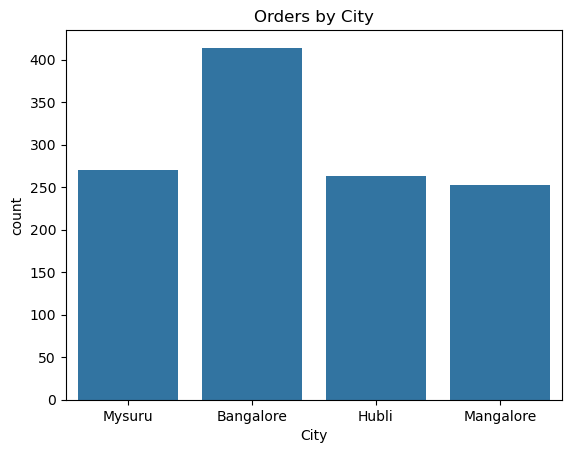

In [103]:
sns.countplot(x="City", data=df1)
plt.title("Orders by City")
plt.show()

# 2. Revenue by City

In [104]:
city_revenue = df1.groupby("City")["Order_Value"].sum().sort_values(ascending=False)
print(city_revenue)

City
Bangalore    193188.44
Hubli        118868.67
Mysuru       118705.64
Mangalore    114130.40
Name: Order_Value, dtype: float64


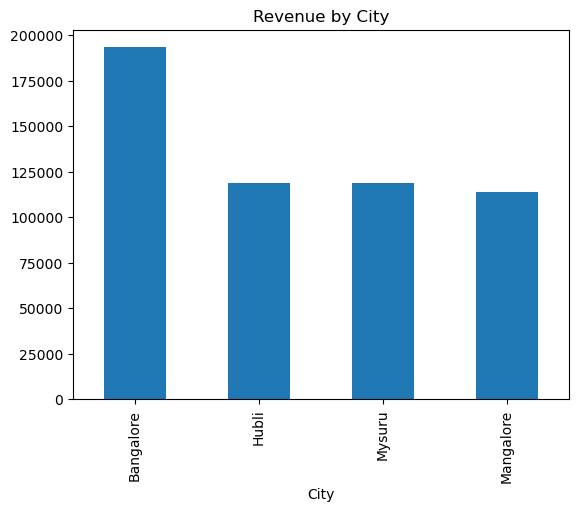

In [105]:
city_revenue.plot(kind="bar")
plt.title("Revenue by City")
plt.show()

# 3. Top Restaurants by Revenue

In [106]:
restaurant_revenue = df1.groupby("Restaurant_Name")["Order_Value"].sum().sort_values(ascending=False)
print(restaurant_revenue.head(10))

Restaurant_Name
Domino'S         120963.80
Mcdonald'S       106632.10
Empire           102198.44
Pizza Hut        101973.35
Meghana Foods     58030.41
Kfc               55095.05
Name: Order_Value, dtype: float64


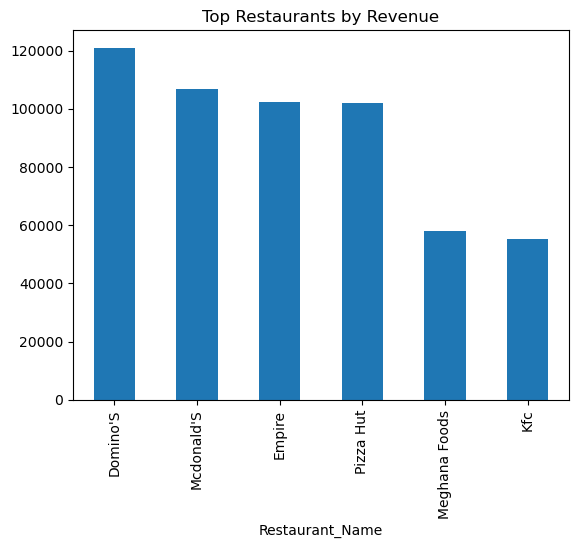

In [107]:
restaurant_revenue.head(10).plot(kind="bar")
plt.title("Top Restaurants by Revenue")
plt.show()

# 4. Average Rating by Restaurant

In [108]:
rating_restaurant = df1.groupby("Restaurant_Name")["Rating"].mean().sort_values(ascending=False)
print(rating_restaurant)

Restaurant_Name
Meghana Foods    3.223823
Domino'S         3.019794
Pizza Hut        2.970551
Kfc              2.961564
Empire           2.934458
Mcdonald'S       2.892006
Name: Rating, dtype: float64


# 5. Most Ordered Items

In [109]:
top_items = df1.groupby("Item_Name")["Quantity"].sum().sort_values(ascending=False)
print(top_items.head(10))

Item_Name
Fries              374
Garlic Bread       336
Chicken Biryani    335
Cheese Pizza       313
Paneer Curry       310
Chicken Pizza      301
Dosa               288
Burger             269
Veg Biryani        265
Veg Pizza          260
Name: Quantity, dtype: int64


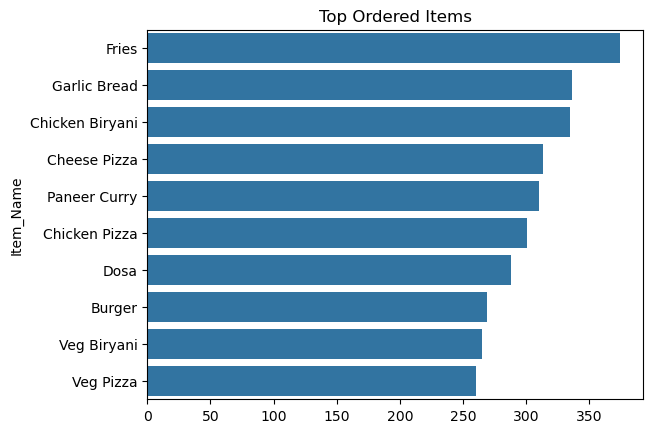

In [110]:
sns.barplot(x=top_items.head(10).values, y=top_items.head(10).index)
plt.title("Top Ordered Items")
plt.show()

# 6. Payment Method Usage

In [111]:
payment = df1["Payment_Method"].value_counts()
print(payment)

Payment_Method
UPI     475
CARD    473
CASH    252
Name: count, dtype: int64


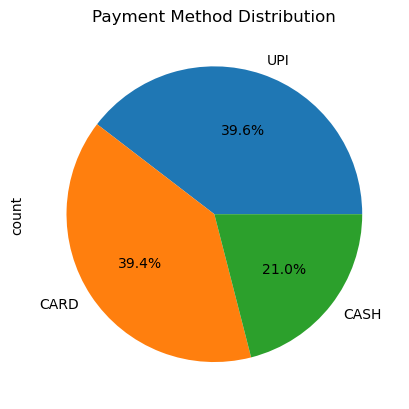

In [112]:
payment.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.show()

# 7. Monthly Order Trend

In [113]:
monthly_orders = df1.groupby("Month")["Order_ID"].count()
print(monthly_orders)

Month
1    127
2    921
3    152
Name: Order_ID, dtype: int64


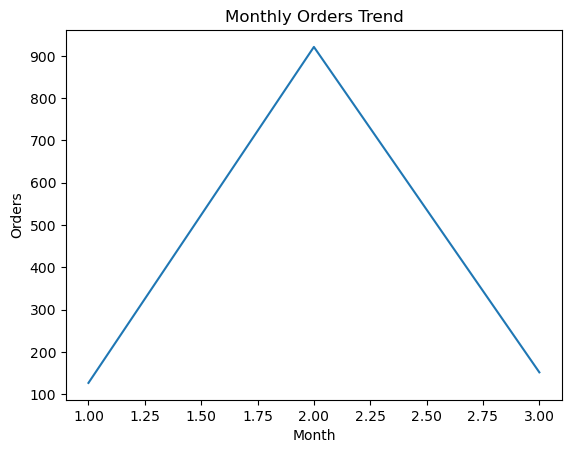

In [114]:
plt.plot(monthly_orders.index, monthly_orders.values)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

# 8. Delivery Time Distribution

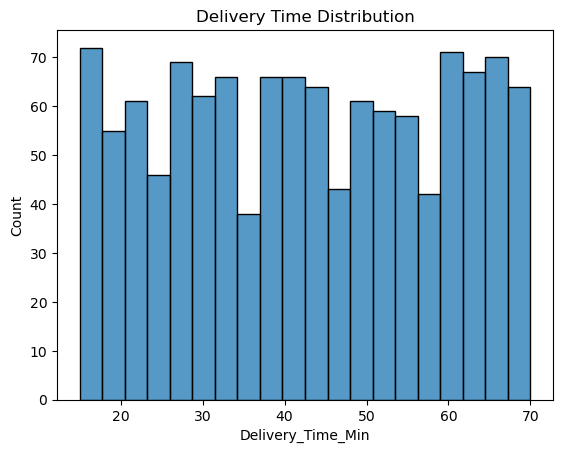

In [115]:
sns.histplot(df1["Delivery_Time_Min"], bins=20)
plt.title("Delivery Time Distribution")
plt.show()

# 9. Delivery Time by City

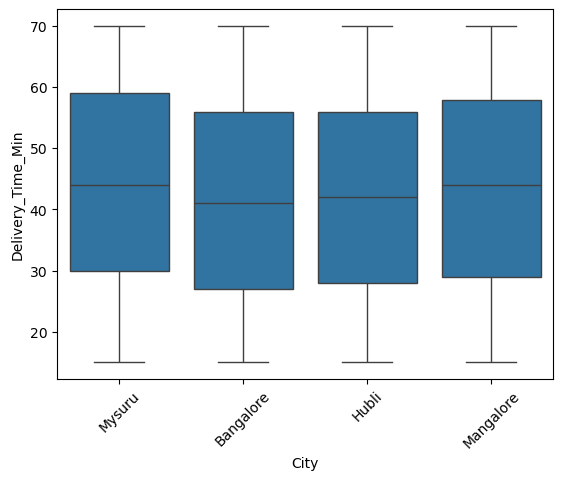

In [116]:
sns.boxplot(x="City", y="Delivery_Time_Min", data=df1)
plt.xticks(rotation=45)
plt.show()

# 10. Delivery Time vs Rating

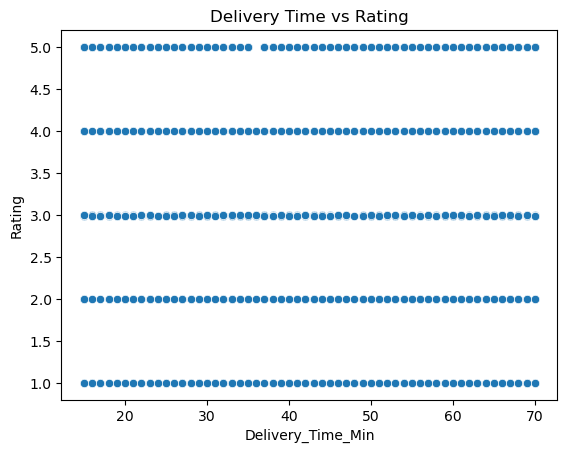

In [117]:
sns.scatterplot(x="Delivery_Time_Min", y="Rating", data=df1)
plt.title("Delivery Time vs Rating")
plt.show()

# 11. Revenue by Food Category

In [118]:
category_revenue = df1.groupby("Food_Category")["Order_Value"].sum()
print(category_revenue)

Food_Category
Biryani         103866.13
Dessert          96143.12
Fast Food       114961.87
North Indian    115914.72
South Indian    114007.31
Name: Order_Value, dtype: float64


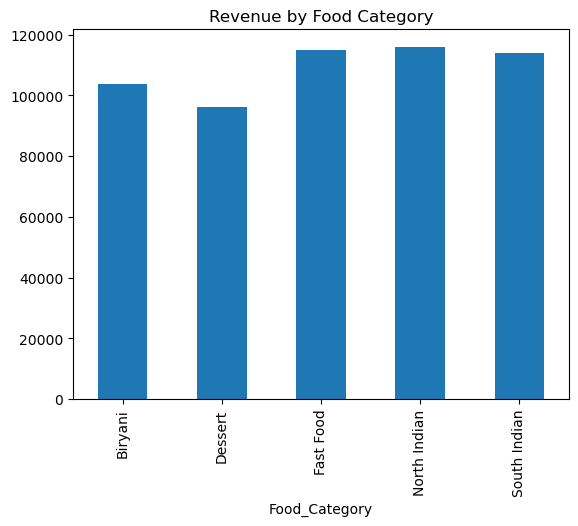

In [119]:
category_revenue.plot(kind="bar")
plt.title("Revenue by Food Category")
plt.show()

# 12. Correlation Analysis

In [120]:
corr = df1.corr(numeric_only=True)

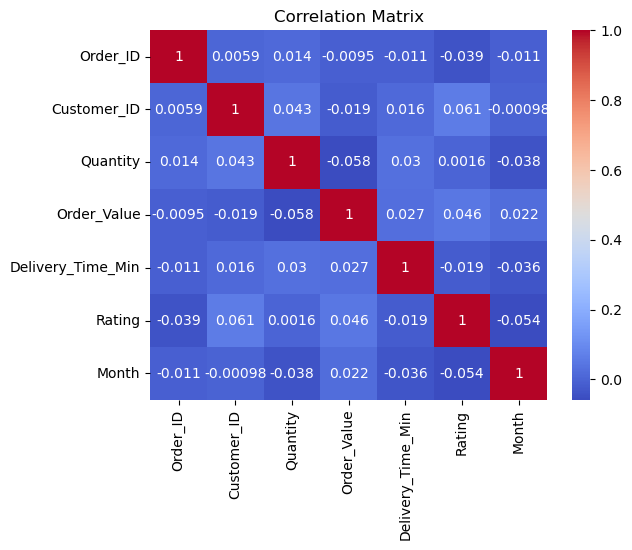

In [121]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 13. Outlier Detection

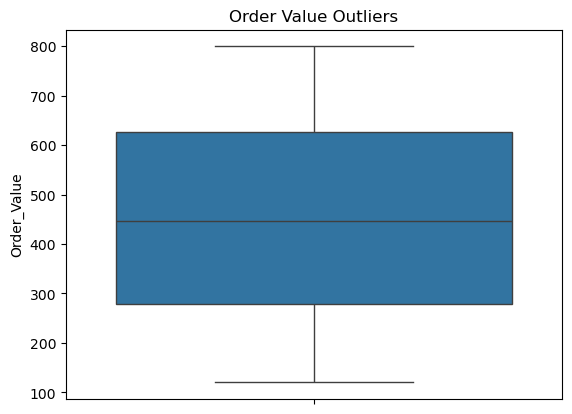

In [122]:
sns.boxplot(df1["Order_Value"])
plt.title("Order Value Outliers")
plt.show()

# 14. Customer Ordering Behavior

In [123]:
customer_orders = df1["Customer_ID"].value_counts()
print(customer_orders.head(10))

Customer_ID
155    9
250    9
44     9
61     9
4      8
68     8
147    8
72     8
126    8
210    8
Name: count, dtype: int64


# 15. Delivery Status vs Ratings

In [124]:
delivery_rating = df1.groupby("Delivery_Status")["Rating"].mean()
print(delivery_rating)

Delivery_Status
Fast      3.051186
Late      2.982682
Normal    2.921858
Name: Rating, dtype: float64


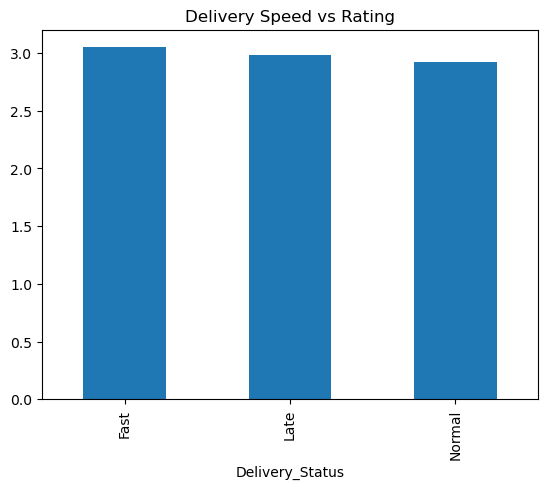

In [125]:
delivery_rating.plot(kind="bar")
plt.title("Delivery Speed vs Rating")
plt.show()

# 16. Average Order Value by City

In [126]:
city_avg_order = df1.groupby("City")["Order_Value"].mean()
print(city_avg_order)

City
Bangalore    466.638744
Hubli        451.972129
Mangalore    451.108300
Mysuru       439.650519
Name: Order_Value, dtype: float64


# 17. Peak Ordering Days

In [127]:
orders_day = df1["Day"].value_counts()
print(orders_day)

Day
Monday       845
Tuesday       66
Friday        65
Sunday        58
Thursday      56
Saturday      56
Wednesday     54
Name: count, dtype: int64


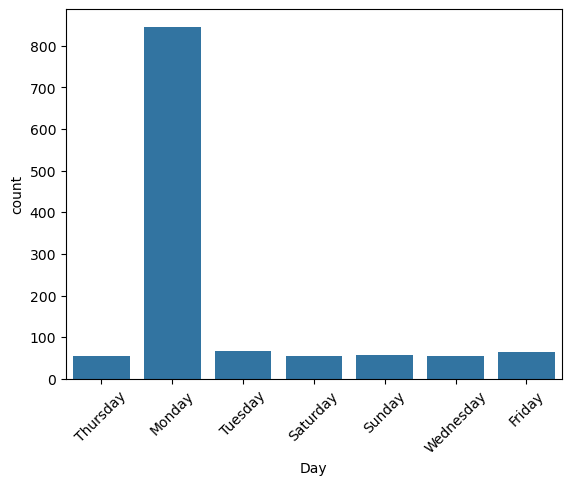

In [128]:
sns.countplot(x="Day", data=df1)
plt.xticks(rotation=45)
plt.show()

# 18. Restaurant Market Share

In [129]:
market_share = df1.groupby("Restaurant_Name")["Order_Value"].sum()
market_share = market_share / market_share.sum() * 100

print(market_share)

Restaurant_Name
Domino'S         22.199545
Empire           18.755684
Kfc              10.111166
Mcdonald'S       19.569360
Meghana Foods    10.649870
Pizza Hut        18.714375
Name: Order_Value, dtype: float64


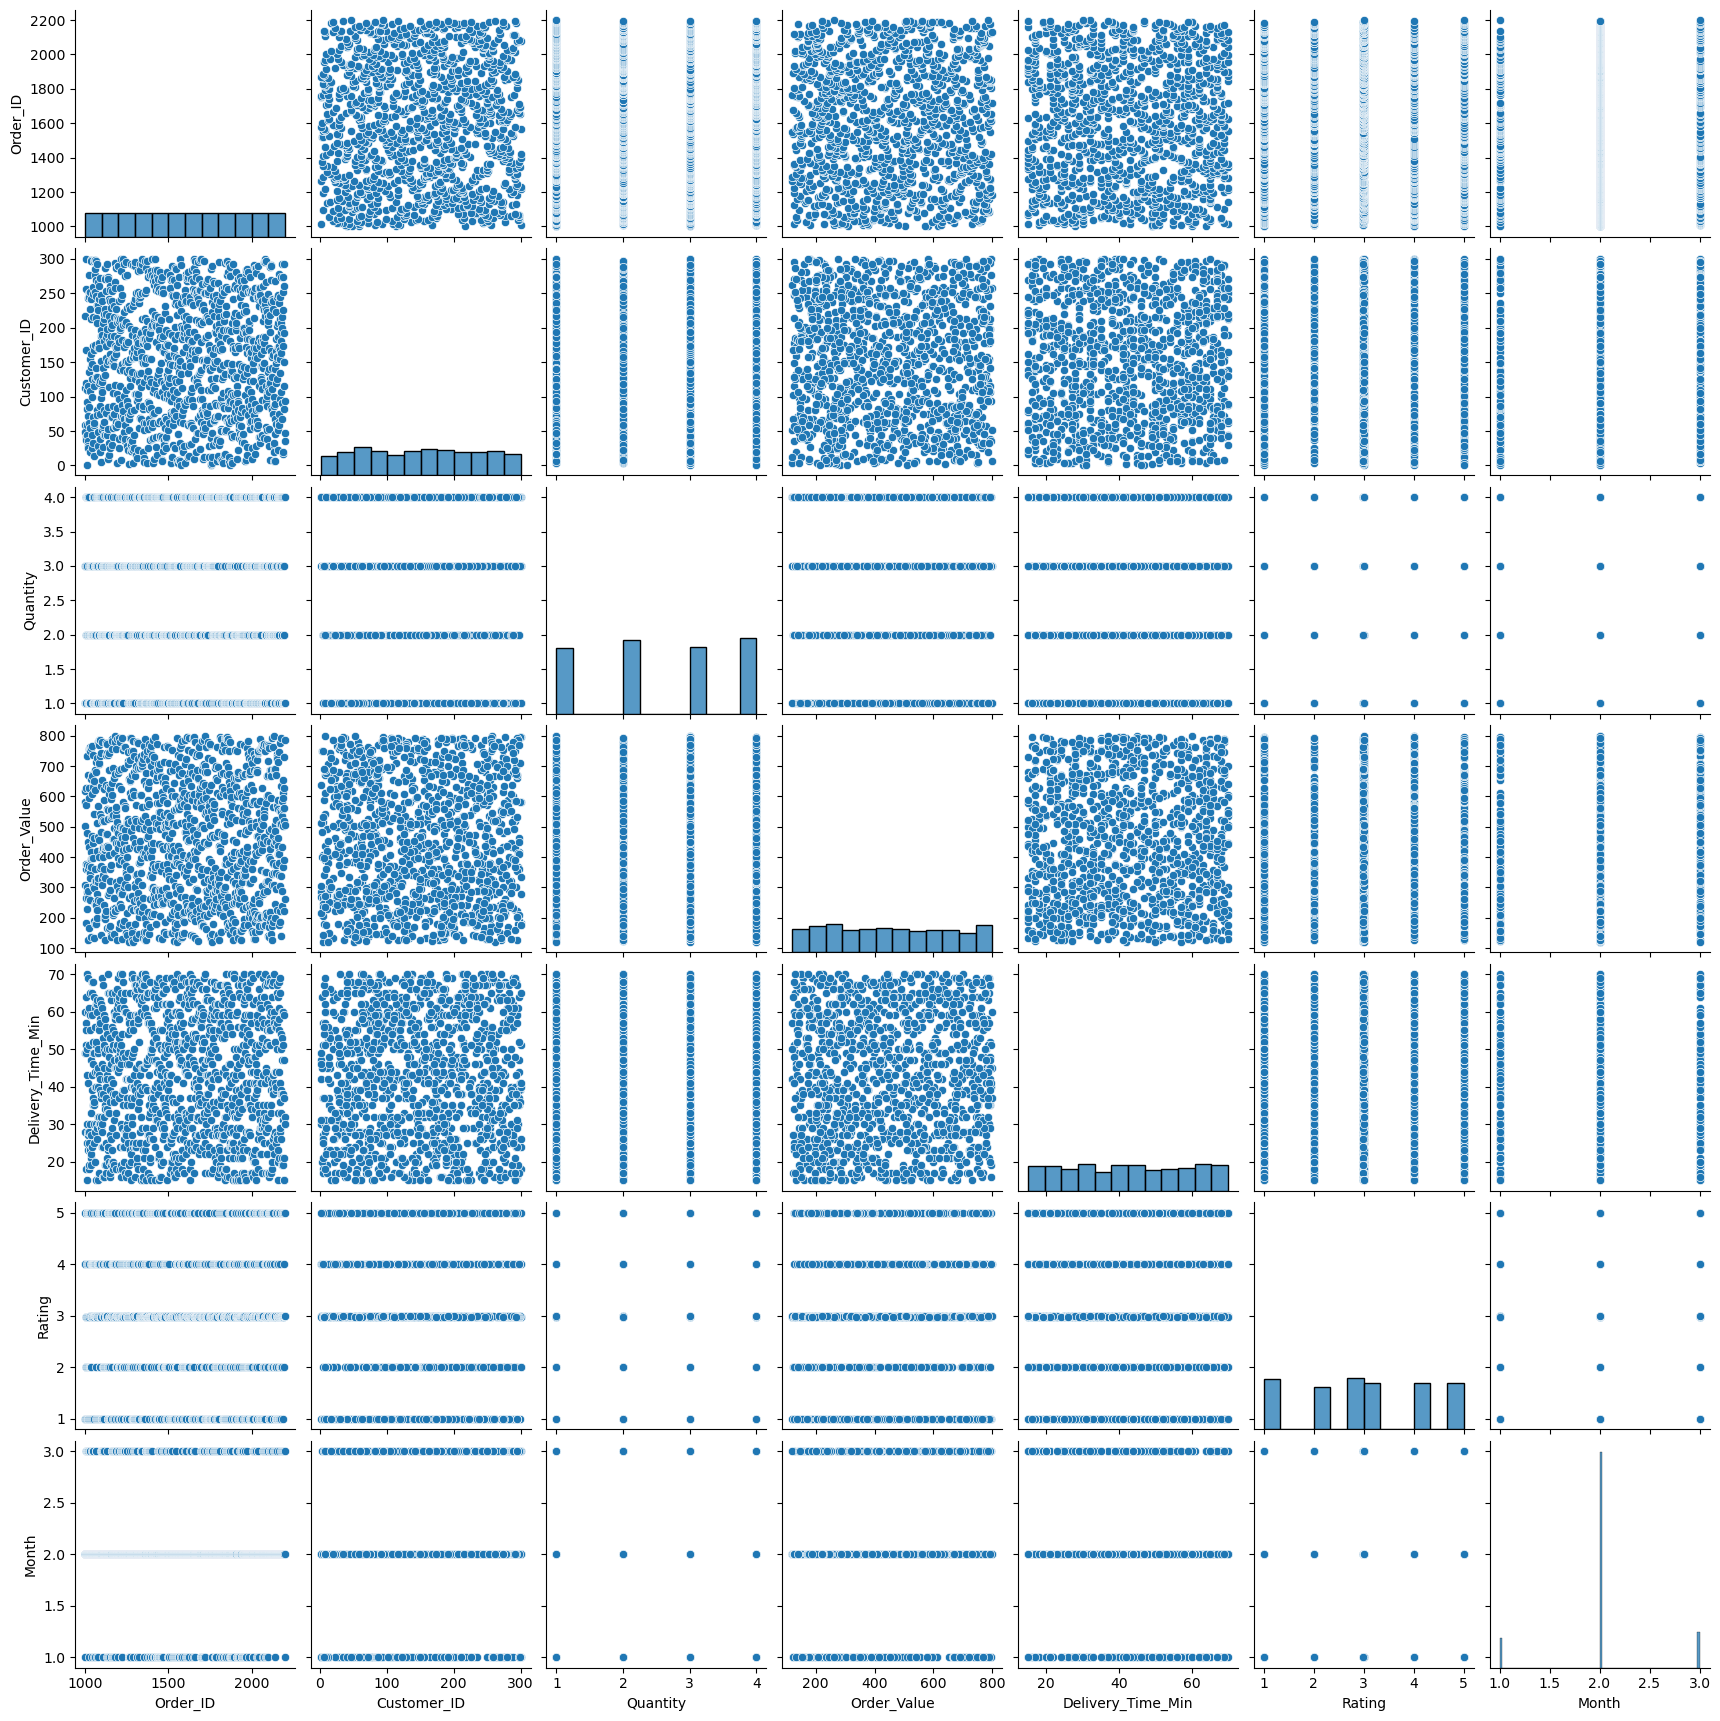

In [130]:
sns.pairplot(data = df1)

# Key Insights from analysis:

**1. City Performance**
1. Bangalore/Bengaluru contributes the highest number of orders and revenue.
2. Cities like Mysuru and Mangalore show moderate demand.
   
**2. Restaurant Performance**
1. A few restaurants dominate:
**High order volume*
**High revenue contribution*
2. Indicates market concentration.
   
**3. Food Category Trends**
1. Fast Food and Biryani are the most popular categories.
2. These categories generate the highest revenue.
   
**4. Payment Behavior**
1. UPI is the most preferred payment method
2. Followed by Card and Cash
3. Shows strong adoption of digital payments.
   
**5. Delivery Performance**
1. Most deliveries fall under 30–45 minutes (Normal).
2. Late deliveries (>45 min) exist but are fewer.
   
**6. Delivery Time vs Rating**
1. Faster deliveries → Higher ratings
2. Late deliveries → Lower ratings
3. Strong negative relationship between delay and satisfaction.
   
**7. Order Trends**
1. Certain days (like weekends) show higher order volume
2. Monthly trend shows consistent demand with slight variations
   
**8. Customer Behavior**
1. A small group of customers:
**Place frequent orders*
**Contribute higher revenue*
2. Indicates loyal/high-value customers.
   
**9. Order Value Insights**
1. Most orders fall within a moderate price range
2. Some high-value outliers exist (bulk orders)
   
**10. Correlation Insights**
1. Weak correlation between:
*Order value and delivery time*
2. Slight negative correlation:
*Delivery time vs rating*

# Conclusion:

1. The business is highly driven by urban cities, especially Bangalore
2. Fast Food and Biryani are key revenue drivers
3. UPI dominates payment methods, indicating digital-first customers
4. Delivery efficiency directly impacts customer satisfaction
5. A small number of restaurants and customers contribute major revenue share